
# Halo Analysis 2.0

This notebook streamlines the halo-analysis workflow for a 3-class U-Net segmentation model.

## What changed
- Removed redundant helper functions and exploratory cells.
- Updated the halo geometry to match the original Fiji logic:
  - **H1**: 4 px band *inside* the nuclear perimeter
  - **H2**: nuclear perimeter reference halo
  - **H3**: first 4 px band *outside* the perimeter
  - **H4**: second 4 px band *outside* the perimeter
- Kept the N/C calculation based on the **nuclear mean** divided by the **mean intensity in the H4−H3 outer ring**.
- Added a full `T × Z` pipeline and time-point summary plots using the **largest nuclear cross-sectional area** at each time point.


In [1]:

import numpy as np
import pandas as pd
from pathlib import Path

import napari
import matplotlib.pyplot as plt
import tensorflow as tf
import tifffile

from scipy import ndimage as ndi
from skimage.transform import resize
from skimage.morphology import remove_small_objects, remove_small_holes
from skimage.measure import label


## Paths and data loading

In [2]:

DATA_ROOT = Path("C:/Users/cowboy/OneDrive/Documents/Unviversity of Alabama")
IMAGE_ROOT = DATA_ROOT / "Nuclear_Scaling/Data_Sets/Control/Extract_3"

IMAGE_PATH = IMAGE_ROOT / "Region 1/Droplet 1/Region 1 Droplet 1 .tif"
MODEL_PATH = DATA_ROOT / "Nuclear_Scaling/Machine_Learning_Models/unet_droplet_nucleus_best_1.2.h5"

assert IMAGE_PATH.exists(), f"Image not found at {IMAGE_PATH}"
assert MODEL_PATH.exists(), f"Model not found at {MODEL_PATH}"

with tifffile.TiffFile(IMAGE_PATH) as tif:
    print("Number of series:", len(tif.series))
    for i, s in enumerate(tif.series):
        print(f"Series {i}")
        print("  shape:", s.shape)
        print("  axes:", s.axes)
        print("  dtype:", s.dtype)

img = tifffile.imread(IMAGE_PATH)
model = tf.keras.models.load_model(MODEL_PATH)

print("Loaded image shape:", img.shape)
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)


Number of series: 1
Series 0
  shape: (10, 20, 3, 392, 396)
  axes: TZCYX
  dtype: uint16


Loaded image shape: (10, 20, 3, 392, 396)
Model input shape: (None, 512, 512, 3)
Model output shape: (None, 512, 512, 3)


## Analysis settings

In [3]:

NUCLEUS_CLASS_IDX = 2
INTENSITY_CHANNEL_IDX = 1

PRED_THRESHOLD = 0.5
MIN_OBJECT_AREA_PX = 100
HOLE_AREA_THRESHOLD = 100

HALO_STEP_PX = 4
MIN_VALID_AREA_PX = 5000
MAX_VALID_AREA_PX = 20000

EXCLUDED_TIMEPOINTS = [0, 1]

pixels_per_um = 6.15
pixel_size_um = 1 / pixels_per_um
pixel_area_um2 = pixel_size_um ** 2

## Helper functions

In [4]:


def extract_plane_yxc(img: np.ndarray, t: int, z: int) -> np.ndarray:
    """Extract one plane from TZCYX data and return (Y, X, C)."""
    plane_cyx = img[t, z, :, :, :]
    plane_yxc = np.moveaxis(plane_cyx, 0, -1)
    return plane_yxc



def prepare_3channel_image_for_unet(image_yxc: np.ndarray, model):
    """Normalize each channel to 0-1 and resize to the model input shape."""
    if image_yxc.ndim != 3:
        raise ValueError(f"Expected (Y, X, C), got {image_yxc.shape}")
    if image_yxc.shape[-1] != 3:
        raise ValueError(f"Expected 3 channels, got {image_yxc.shape[-1]}")

    _, target_h, target_w, target_c = model.input_shape
    if target_c != 3:
        raise ValueError(f"Model expects {target_c} channels")

    original_shape = image_yxc.shape[:2]
    x = image_yxc.astype(np.float32).copy()

    for c in range(3):
        ch = x[..., c]
        ch_min = ch.min()
        ch_max = ch.max()
        if ch_max > ch_min:
            x[..., c] = (ch - ch_min) / (ch_max - ch_min)
        else:
            x[..., c] = np.zeros_like(ch, dtype=np.float32)

    x_resized = resize(
        x,
        (target_h, target_w, target_c),
        order=1,
        mode="reflect",
        anti_aliasing=True,
        preserve_range=True,
    ).astype(np.float32)

    x_in = x_resized[None, ...]
    return x_in, original_shape



def resize_prob_map_to_original(prob_map: np.ndarray, original_shape: tuple) -> np.ndarray:
    """Resize a model output map back to the original YX shape."""
    return resize(
        prob_map,
        original_shape,
        order=1,
        mode="reflect",
        anti_aliasing=False,
        preserve_range=True,
    ).astype(np.float32)



def clean_nucleus_mask(
    nucleus_mask: np.ndarray,
    min_area_px: int = 100,
    hole_area_threshold: int = 100,
    keep_largest: bool = True,
) -> np.ndarray:
    """Clean the raw binary mask and optionally keep only the largest object."""
    mask = nucleus_mask.astype(bool)
    mask = remove_small_holes(mask, area_threshold=hole_area_threshold)
    mask = remove_small_objects(mask, min_size=min_area_px)

    if keep_largest:
        lab = label(mask)
        if lab.max() > 0:
            areas = [(lab == i).sum() for i in range(1, lab.max() + 1)]
            largest_id = np.argmax(areas) + 1
            mask = lab == largest_id

    return mask



def compute_signed_distance_map(nucleus_mask: np.ndarray) -> np.ndarray:
    """Negative inside the nucleus, positive outside."""
    nucleus_mask = nucleus_mask.astype(bool)
    dist_outside = ndi.distance_transform_edt(~nucleus_mask)
    dist_inside = ndi.distance_transform_edt(nucleus_mask)

    signed_dist = dist_outside.copy()
    signed_dist[nucleus_mask] = -dist_inside[nucleus_mask]
    return signed_dist



def measure_mask(mask: np.ndarray, intensity_image: np.ndarray) -> dict:
    """Measure area and intensity statistics for a binary mask."""
    mask = mask.astype(bool)
    vals = intensity_image[mask]
    area_px = int(mask.sum())

    if vals.size == 0:
        return {
            "area_px": area_px,
            "sum_intensity": 0.0,
            "mean_intensity": np.nan,
            "median_intensity": np.nan,
            "std_intensity": np.nan,
        }

    return {
        "area_px": area_px,
        "sum_intensity": float(vals.sum()),
        "mean_intensity": float(vals.mean()),
        "median_intensity": float(np.median(vals)),
        "std_intensity": float(vals.std()),
    }



def build_boundary_centered_halos(
    signed_dist: np.ndarray,
    step_px: int = 4,
    valid_outer_mask: np.ndarray | None = None,
) -> dict:
    """
    Boundary-centered halo geometry matching the Fiji workflow.

    H1: inside band  (-step, 0]
    H2: perimeter reference halo (narrow band around 0)
    H3: first outer band (0, step]
    H4: second outer band (step, 2*step]

    Also returns cumulative outer halos for Fiji-style subtraction:
    H3_cum: (0, step]
    H4_cum: (0, 2*step]
    """
    if valid_outer_mask is None:
        valid_outer_mask = np.ones_like(signed_dist, dtype=bool)
    else:
        valid_outer_mask = valid_outer_mask.astype(bool)

    halos = {
        "H1": (signed_dist > -step_px) & (signed_dist <= 0),
        "H2": np.abs(signed_dist) <= 0.5,
        "H3": (signed_dist > 0) & (signed_dist <= step_px) & valid_outer_mask,
        "H4": (signed_dist > step_px) & (signed_dist <= 2 * step_px) & valid_outer_mask,
        "H3_cum": (signed_dist > 0) & (signed_dist <= step_px) & valid_outer_mask,
        "H4_cum": (signed_dist > 0) & (signed_dist <= 2 * step_px) & valid_outer_mask,
    }
    return halos



def build_boundary_halo_measurement_table(
    nucleus_mask: np.ndarray,
    signed_dist: np.ndarray,
    intensity_image: np.ndarray,
    step_px: int = 4,
    valid_outer_mask: np.ndarray | None = None,
    t: int | None = None,
    z: int | None = None,
    nucleus_id: int | None = None,
) -> pd.DataFrame:
    """Build a one-row measurement table for one nucleus in one plane."""
    nucleus_mask = nucleus_mask.astype(bool)
    halos = build_boundary_centered_halos(
        signed_dist=signed_dist,
        step_px=step_px,
        valid_outer_mask=valid_outer_mask,
    )

    nuc_stats = measure_mask(nucleus_mask, intensity_image)
    h1_stats = measure_mask(halos["H1"], intensity_image)
    h2_stats = measure_mask(halos["H2"], intensity_image)
    h3_stats = measure_mask(halos["H3"], intensity_image)
    h4_stats = measure_mask(halos["H4"], intensity_image)
    h3_cum_stats = measure_mask(halos["H3_cum"], intensity_image)
    h4_cum_stats = measure_mask(halos["H4_cum"], intensity_image)

    cyto_ring_area = h4_cum_stats["area_px"] - h3_cum_stats["area_px"]
    cyto_ring_sum = h4_cum_stats["sum_intensity"] - h3_cum_stats["sum_intensity"]
    cyto_ring_mean = cyto_ring_sum / cyto_ring_area if cyto_ring_area > 0 else np.nan

    nc_ratio = (
        nuc_stats["mean_intensity"] / cyto_ring_mean
        if (not np.isnan(cyto_ring_mean) and cyto_ring_mean != 0)
        else np.nan
    )

    row = {
        "nuclear_area_px": nuc_stats["area_px"],
        "nuclear_sum_intensity": nuc_stats["sum_intensity"],
        "nuclear_mean_intensity": nuc_stats["mean_intensity"],
        "nuclear_median_intensity": nuc_stats["median_intensity"],
        "nuclear_std_intensity": nuc_stats["std_intensity"],
        "H1_area_px": h1_stats["area_px"],
        "H1_mean_intensity": h1_stats["mean_intensity"],
        "H1_sum_intensity": h1_stats["sum_intensity"],
        "H2_area_px": h2_stats["area_px"],
        "H2_mean_intensity": h2_stats["mean_intensity"],
        "H2_sum_intensity": h2_stats["sum_intensity"],
        "H3_area_px": h3_stats["area_px"],
        "H3_mean_intensity": h3_stats["mean_intensity"],
        "H3_sum_intensity": h3_stats["sum_intensity"],
        "H4_area_px": h4_stats["area_px"],
        "H4_mean_intensity": h4_stats["mean_intensity"],
        "H4_sum_intensity": h4_stats["sum_intensity"],
        "H3_cum_area_px": h3_cum_stats["area_px"],
        "H3_cum_sum_intensity": h3_cum_stats["sum_intensity"],
        "H4_cum_area_px": h4_cum_stats["area_px"],
        "H4_cum_sum_intensity": h4_cum_stats["sum_intensity"],
        "cyto_ring_area_px": cyto_ring_area,
        "cyto_ring_sum_intensity": cyto_ring_sum,
        "cyto_ring_mean_intensity": cyto_ring_mean,
        "nc_ratio": nc_ratio,
    }

    if t is not None:
        row["t"] = t
    if z is not None:
        row["z"] = z
    if nucleus_id is not None:
        row["nucleus_id"] = nucleus_id

    return pd.DataFrame([row])



def analyze_single_plane(
    plane_yxc: np.ndarray,
    model,
    nucleus_class_idx: int,
    intensity_channel_idx: int,
    pred_threshold: float = 0.5,
    min_area_px: int = 100,
    hole_area_threshold: int = 100,
    halo_step_px: int = 4,
    valid_outer_mask: np.ndarray | None = None,
    min_valid_area_px: int = 5000,
    max_valid_area_px: int = 20000,
    t: int | None = None,
    z: int | None = None,
):
    """Analyze one plane and return a table plus QC arrays."""
    x_in, original_shape = prepare_3channel_image_for_unet(plane_yxc, model)
    pred = model.predict(x_in, verbose=0)

    nucleus_prob_512 = pred[0, ..., nucleus_class_idx]
    nucleus_prob_orig = resize_prob_map_to_original(nucleus_prob_512, original_shape)

    nucleus_mask_raw = nucleus_prob_orig >= pred_threshold
    nucleus_mask = clean_nucleus_mask(
        nucleus_mask_raw,
        min_area_px=min_area_px,
        hole_area_threshold=hole_area_threshold,
        keep_largest=True,
    )

    empty_row = pd.DataFrame([
        {
            "t": t,
            "z": z,
            "nucleus_id": 1,
            "nuclear_area_px": 0,
            "nc_ratio": np.nan,
        }
    ])

    if nucleus_mask.sum() == 0:
        return {
            "table": empty_row,
            "nucleus_mask": nucleus_mask,
            "nucleus_prob": nucleus_prob_orig,
            "signed_dist": None,
        }

    area = nucleus_mask.sum()
    if area < min_valid_area_px or area > max_valid_area_px:
        return {
            "table": empty_row,
            "nucleus_mask": nucleus_mask,
            "nucleus_prob": nucleus_prob_orig,
            "signed_dist": None,
        }

    signed_dist = compute_signed_distance_map(nucleus_mask)
    intensity_image = plane_yxc[..., intensity_channel_idx]

    table = build_boundary_halo_measurement_table(
        nucleus_mask=nucleus_mask,
        signed_dist=signed_dist,
        intensity_image=intensity_image,
        step_px=halo_step_px,
        valid_outer_mask=valid_outer_mask,
        t=t,
        z=z,
        nucleus_id=1,
    )

    return {
        "table": table,
        "nucleus_mask": nucleus_mask,
        "nucleus_prob": nucleus_prob_orig,
        "signed_dist": signed_dist,
    }



def analyze_all_tz_planes(
    img: np.ndarray,
    model,
    nucleus_class_idx: int,
    intensity_channel_idx: int,
    pred_threshold: float = 0.5,
    min_area_px: int = 100,
    hole_area_threshold: int = 100,
    halo_step_px: int = 4,
    min_valid_area_px: int = 5000,
    max_valid_area_px: int = 20000,
):
    """Run the full halo analysis across all time points and z-slices."""
    n_t, n_z = img.shape[0], img.shape[1]
    all_tables = []

    for t in range(n_t):
        for z in range(n_z):
            print(f"Processing t={t}, z={z}")
            plane_yxc = extract_plane_yxc(img, t=t, z=z)
            res = analyze_single_plane(
                plane_yxc=plane_yxc,
                model=model,
                nucleus_class_idx=nucleus_class_idx,
                intensity_channel_idx=intensity_channel_idx,
                pred_threshold=pred_threshold,
                min_area_px=min_area_px,
                hole_area_threshold=hole_area_threshold,
                halo_step_px=halo_step_px,
                valid_outer_mask=None,
                min_valid_area_px=min_valid_area_px,
                max_valid_area_px=max_valid_area_px,
                t=t,
                z=z,
            )
            all_tables.append(res["table"])

    return pd.concat(all_tables, ignore_index=True)


## Single-plane quality control

In [5]:

TEST_T = 9
TEST_Z = 15

plane_yxc = extract_plane_yxc(img, t=TEST_T, z=TEST_Z)
result = analyze_single_plane(
    plane_yxc=plane_yxc,
    model=model,
    nucleus_class_idx=NUCLEUS_CLASS_IDX,
    intensity_channel_idx=INTENSITY_CHANNEL_IDX,
    pred_threshold=PRED_THRESHOLD,
    min_area_px=MIN_OBJECT_AREA_PX,
    hole_area_threshold=HOLE_AREA_THRESHOLD,
    halo_step_px=HALO_STEP_PX,
    min_valid_area_px=MIN_VALID_AREA_PX,
    max_valid_area_px=MAX_VALID_AREA_PX,
    t=TEST_T,
    z=TEST_Z,
)

result["table"].T


,0
nuclear_area_px,1.357900e+04
nuclear_sum_intensity,2.880134e+07
nuclear_mean_intensity,2.121020e+03
nuclear_median_intensity,2.181000e+03
nuclear_std_intensity,2.792844e+02
H1_area_px,1.400000e+03
H1_mean_intensity,1.541888e+03
H1_sum_intensity,2.158643e+06
H2_area_px,0.000000e+00
H2_mean_intensity,NaN


In [5]:

signed_dist = result["signed_dist"]
nucleus_mask = result["nucleus_mask"]
nucleus_prob = result["nucleus_prob"]
intensity_image = plane_yxc[..., INTENSITY_CHANNEL_IDX]

halos = build_boundary_centered_halos(signed_dist=signed_dist, step_px=HALO_STEP_PX)
viewer = napari.Viewer()
viewer.add_image(plane_yxc, name="original_plane", channel_axis=2)
viewer.add_image(nucleus_prob, name="nucleus_probability")
viewer.add_labels(nucleus_mask.astype(int), name="nucleus_mask", opacity=0.35)
viewer.add_labels(halos["H1"].astype(int), name="H1_inside", opacity=0.45)
viewer.add_labels(halos["H2"].astype(int), name="H2_perimeter", opacity=0.55)
viewer.add_labels(halos["H3"].astype(int), name="H3_outer", opacity=0.45)
viewer.add_labels(halos["H4"].astype(int), name="H4_outer", opacity=0.45)


NameError: name 'result' is not defined

## Full T × Z analysis

In [5]:

results_df = analyze_all_tz_planes(
    img=img,
    model=model,
    nucleus_class_idx=NUCLEUS_CLASS_IDX,
    intensity_channel_idx=INTENSITY_CHANNEL_IDX,
    pred_threshold=PRED_THRESHOLD,
    min_area_px=MIN_OBJECT_AREA_PX,
    hole_area_threshold=HOLE_AREA_THRESHOLD,
    halo_step_px=HALO_STEP_PX,
    min_valid_area_px=MIN_VALID_AREA_PX,
    max_valid_area_px=MAX_VALID_AREA_PX,
)

print(results_df.shape)
results_df.head()


Processing t=0, z=0
Processing t=0, z=1
Processing t=0, z=2
Processing t=0, z=3
Processing t=0, z=4
Processing t=0, z=5
Processing t=0, z=6
Processing t=0, z=7
Processing t=0, z=8
Processing t=0, z=9
Processing t=0, z=10
Processing t=0, z=11
Processing t=0, z=12
Processing t=0, z=13
Processing t=0, z=14
Processing t=0, z=15
Processing t=0, z=16
Processing t=0, z=17
Processing t=0, z=18
Processing t=0, z=19
Processing t=1, z=0
Processing t=1, z=1
Processing t=1, z=2
Processing t=1, z=3
Processing t=1, z=4
Processing t=1, z=5
Processing t=1, z=6
Processing t=1, z=7
Processing t=1, z=8
Processing t=1, z=9
Processing t=1, z=10
Processing t=1, z=11
Processing t=1, z=12
Processing t=1, z=13
Processing t=1, z=14
Processing t=1, z=15
Processing t=1, z=16
Processing t=1, z=17
Processing t=1, z=18
Processing t=1, z=19
Processing t=2, z=0
Processing t=2, z=1
Processing t=2, z=2
Processing t=2, z=3
Processing t=2, z=4
Processing t=2, z=5
Processing t=2, z=6
Processing t=2, z=7
Processing t=2, z=8


,nuclear_area_px,nuclear_sum_intensity,nuclear_mean_intensity,nuclear_median_intensity,nuclear_std_intensity,H1_area_px,H1_mean_intensity,H1_sum_intensity,H2_area_px,H2_mean_intensity,...,H3_cum_sum_intensity,H4_cum_area_px,H4_cum_sum_intensity,cyto_ring_area_px,cyto_ring_sum_intensity,cyto_ring_mean_intensity,nc_ratio,t,z,nucleus_id
0,5181,2185981.0,421.922602,421.0,29.393581,1356.0,412.967552,559984.0,0.0,NaN,...,593312.0,2907.0,1110823.0,1382.0,517511.0,374.465268,1.126734,0,0,1
1,10433,4810797.0,461.113486,461.0,33.041869,2524.0,448.970285,1133201.0,0.0,NaN,...,1109598.0,4774.0,1973238.0,2159.0,863640.0,400.018527,1.152730,0,1,1
2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,1
3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3,1
4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4,1


## Largest cross-sectional area per time point

In [6]:
print(results_df.shape)
print(results_df.columns.tolist())
print(results_df["nuclear_area_px"].dtype)
print(results_df["t"].dtype)
print(results_df[["t", "z", "nuclear_area_px", "nc_ratio"]].head())

(200, 28)
['nuclear_area_px', 'nuclear_sum_intensity', 'nuclear_mean_intensity', 'nuclear_median_intensity', 'nuclear_std_intensity', 'H1_area_px', 'H1_mean_intensity', 'H1_sum_intensity', 'H2_area_px', 'H2_mean_intensity', 'H2_sum_intensity', 'H3_area_px', 'H3_mean_intensity', 'H3_sum_intensity', 'H4_area_px', 'H4_mean_intensity', 'H4_sum_intensity', 'H3_cum_area_px', 'H3_cum_sum_intensity', 'H4_cum_area_px', 'H4_cum_sum_intensity', 'cyto_ring_area_px', 'cyto_ring_sum_intensity', 'cyto_ring_mean_intensity', 'nc_ratio', 't', 'z', 'nucleus_id']
int64
int64
   t  z  nuclear_area_px  nc_ratio
0  0  0             5181  1.126734
1  0  1            10433  1.152730
2  0  2                0       NaN
3  0  3                0       NaN
4  0  4                0       NaN


In [7]:

plot_df = results_df[results_df["nuclear_area_px"] > 0].copy()
idx = plot_df.groupby("t")["nuclear_area_px"].idxmax()

largest_area_df = (
    plot_df.loc[idx]
    .sort_values("t")
    .reset_index(drop=True)
)

largest_area_df[["t", "z", "nuclear_area_px", "nc_ratio"]]


,t,z,nuclear_area_px,nc_ratio
0,0,14,11662,1.064212
1,1,3,13934,1.122366
2,2,0,7204,1.193032
3,3,11,8584,7.049737
4,4,11,10550,7.953282
5,5,12,12058,8.192390
6,6,13,12982,9.082411
7,7,13,13338,7.969985
8,8,14,13498,7.693009
9,9,15,13579,7.839020


In [8]:

largest_area_df_filtered = largest_area_df[
    ~largest_area_df["t"].isin(EXCLUDED_TIMEPOINTS)
].copy()

largest_area_df_filtered[["t", "z", "nuclear_area_px", "nc_ratio"]]


,t,z,nuclear_area_px,nc_ratio
2,2,0,7204,1.193032
3,3,11,8584,7.049737
4,4,11,10550,7.953282
5,5,12,12058,8.192390
6,6,13,12982,9.082411
7,7,13,13338,7.969985
8,8,14,13498,7.693009
9,9,15,13579,7.839020


In [9]:
largest_area_df_filtered = largest_area_df_filtered.copy()

# Option A
largest_area_df_filtered["area_um2_optionA"] = (
    largest_area_df_filtered["nuclear_area_px"] * 6.15
)

# Option B
pixels_per_um = 6.15
pixel_size_um = 1 / pixels_per_um
pixel_area_um2 = pixel_size_um ** 2

largest_area_df_filtered["area_um2_optionB"] = (
    largest_area_df_filtered["nuclear_area_px"] * pixel_area_um2
)

## Time-course plots

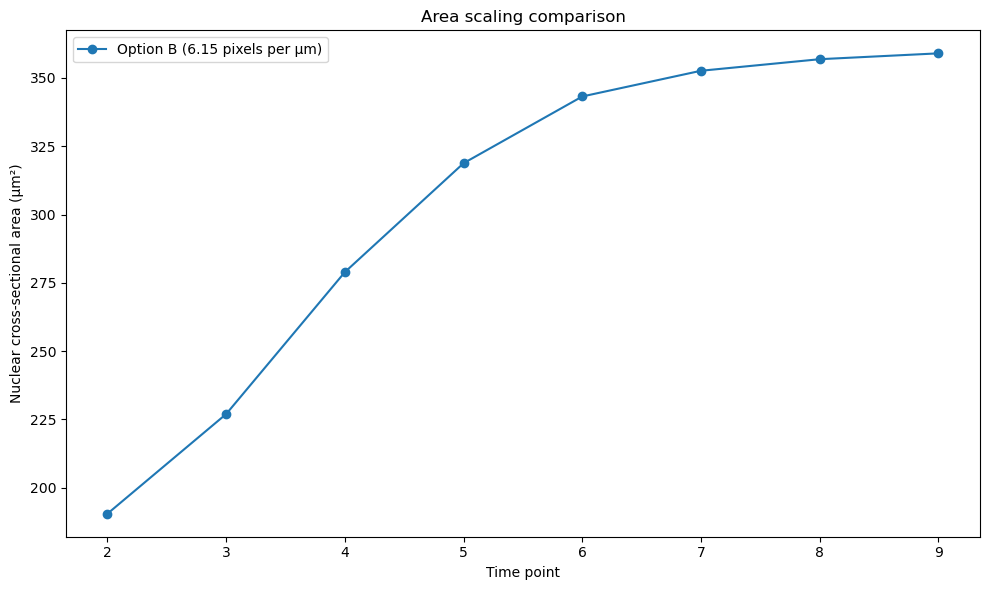

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))


plt.plot(
    largest_area_df_filtered["t"],
    largest_area_df_filtered["area_um2_optionB"],
    marker="o",
    label="Option B (6.15 pixels per µm)"
)

plt.xlabel("Time point")
plt.ylabel("Nuclear cross-sectional area (µm²)")
plt.title("Area scaling comparison")
plt.legend()
plt.tight_layout()
plt.show()

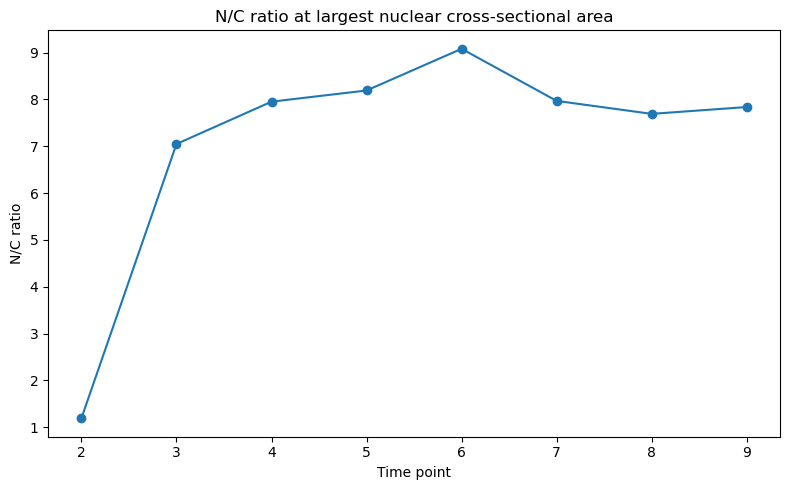

In [11]:

plt.figure(figsize=(8, 5))
plt.plot(
    largest_area_df_filtered["t"],
    largest_area_df_filtered["nc_ratio"],
    marker="o"
)
plt.xlabel("Time point")
plt.ylabel("N/C ratio")
plt.title("N/C ratio at largest nuclear cross-sectional area")
plt.tight_layout()
plt.show()


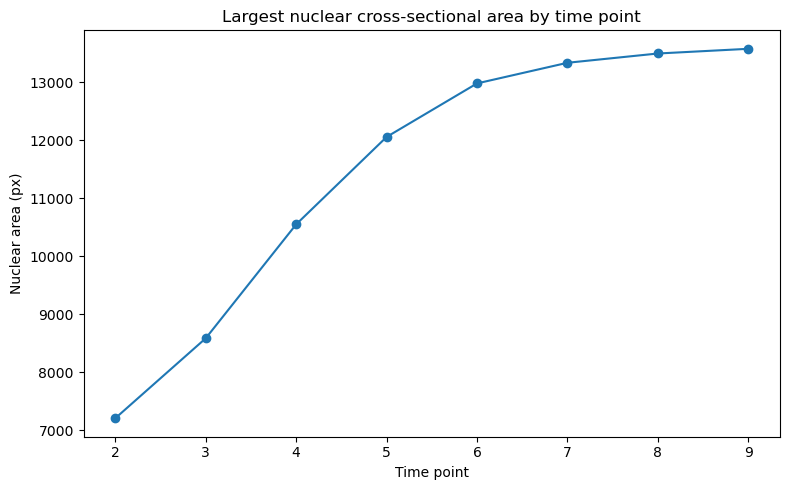

In [12]:

plt.figure(figsize=(8, 5))
plt.plot(
    largest_area_df_filtered["t"],
    largest_area_df_filtered["nuclear_area_px"],
    marker="o"
)
plt.xlabel("Time point")
plt.ylabel("Nuclear area (px)")
plt.title("Largest nuclear cross-sectional area by time point")
plt.tight_layout()
plt.show()


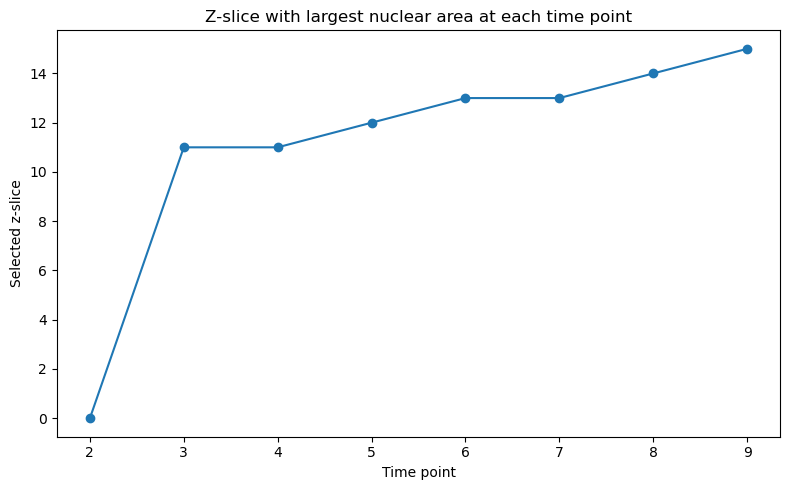

In [13]:

plt.figure(figsize=(8, 5))
plt.plot(
    largest_area_df_filtered["t"],
    largest_area_df_filtered["z"],
    marker="o"
)
plt.xlabel("Time point")
plt.ylabel("Selected z-slice")
plt.title("Z-slice with largest nuclear area at each time point")
plt.tight_layout()
plt.show()


In [9]:
pixel_area_um2 = 0.1626 ** 2
print(pixel_area_um2)

0.02643876


In [10]:
largest_area_df_filtered = largest_area_df_filtered.copy()

pixel_size_um = 0.1626  # example, replace with your real value
pixel_area_um2 = pixel_size_um ** 2

largest_area_df_filtered["cyto_ring_mean_per_um2"] = (
    largest_area_df_filtered["cyto_ring_sum_intensity"] /
    (largest_area_df_filtered["cyto_ring_area_px"] * pixel_area_um2)
)

largest_area_df_filtered["nc_ratio_um2_denominator"] = (
    largest_area_df_filtered["nuclear_mean_intensity"] /
    largest_area_df_filtered["cyto_ring_mean_per_um2"]
)

print(
    largest_area_df_filtered[
        ["t", "nc_ratio", "nc_ratio_um2_denominator"]
    ]
)

   t  nc_ratio  nc_ratio_um2_denominator
2  2  1.193032                  0.031542
3  3  7.049737                  0.186386
4  4  7.953282                  0.210275
5  5  8.192390                  0.216597
6  6  9.082411                  0.240128
7  7  7.969985                  0.210717
8  8  7.693009                  0.203394
9  9  7.839020                  0.207254


In [11]:
largest_area_df_filtered["nc_ratio_fixed"] = (
    (largest_area_df_filtered["nuclear_mean_intensity"] / pixel_area_um2) /
    largest_area_df_filtered["cyto_ring_mean_per_um2"]
)

In [12]:
# Estimate a global background from all intensity values (safe fallback)
# You can refine this later per-plane if needed
background = results_df["nuclear_mean_intensity"].min() * 0.1

largest_area_df_filtered = largest_area_df_filtered.copy()

largest_area_df_filtered["nc_ratio_bgsub"] = (
    (largest_area_df_filtered["nuclear_mean_intensity"] - background) /
    (largest_area_df_filtered["cyto_ring_mean_intensity"] - background)
)

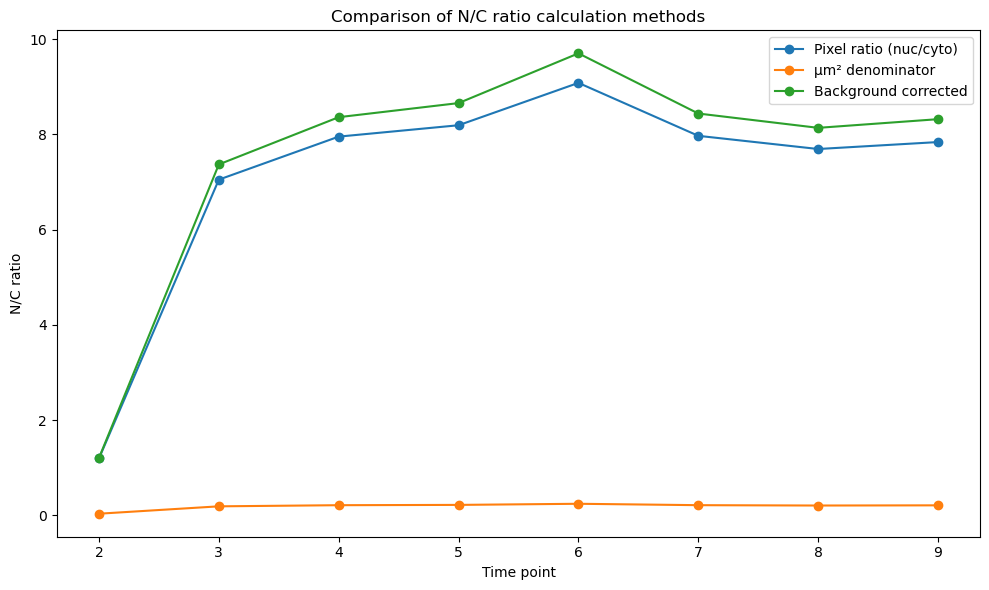

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Pixel-based ratio (current)
plt.plot(
    largest_area_df_filtered["t"],
    largest_area_df_filtered["nc_ratio"],
    marker="o",
    label="Pixel ratio (nuc/cyto)"
)

# µm² denominator version
plt.plot(
    largest_area_df_filtered["t"],
    largest_area_df_filtered["nc_ratio_um2_denominator"],
    marker="o",
    label="µm² denominator"
)

# Background-subtracted version
plt.plot(
    largest_area_df_filtered["t"],
    largest_area_df_filtered["nc_ratio_bgsub"],
    marker="o",
    label="Background corrected"
)

plt.xlabel("Time point")
plt.ylabel("N/C ratio")
plt.title("Comparison of N/C ratio calculation methods")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
largest_area_df_filtered = largest_area_df_filtered.copy()

largest_area_df_filtered["cyto_ring_mean_per_um2_alt"] = (
    largest_area_df_filtered["cyto_ring_sum_intensity"] /
    (largest_area_df_filtered["cyto_ring_area_px"] * pixel_area_um2)
)

largest_area_df_filtered["nc_ratio_um2_alt"] = (
    largest_area_df_filtered["nuclear_mean_intensity"] /
    largest_area_df_filtered["cyto_ring_mean_per_um2_alt"]
)

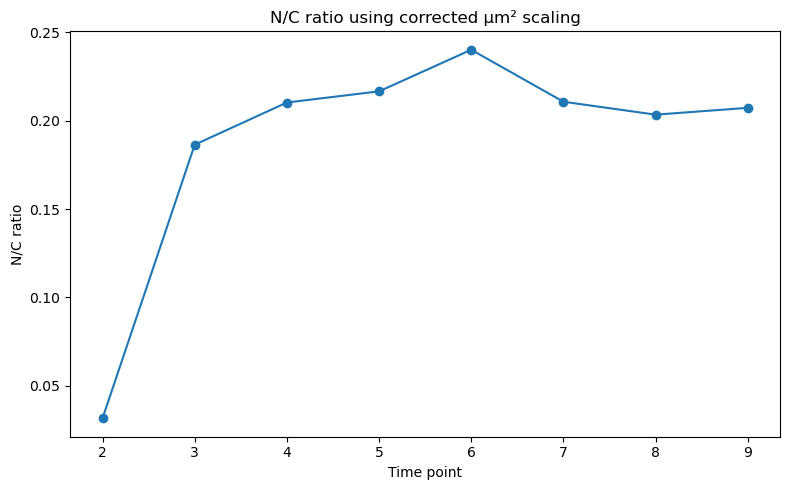

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    largest_area_df_filtered["t"],
    largest_area_df_filtered["nc_ratio_um2_alt"],
    marker="o"
)
plt.xlabel("Time point")
plt.ylabel("N/C ratio")
plt.title("N/C ratio using corrected µm² scaling")
plt.tight_layout()
plt.show()

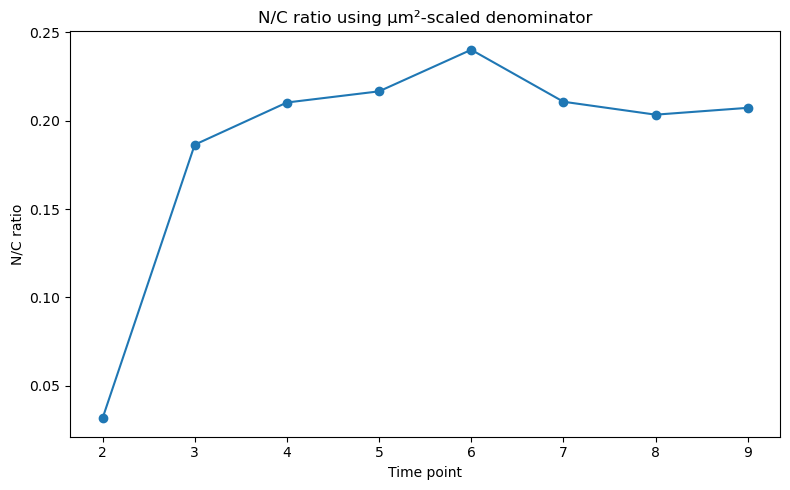

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    largest_area_df_filtered["t"],
    largest_area_df_filtered["nc_ratio_um2_denominator"],
    marker="o"
)
plt.xlabel("Time point")
plt.ylabel("N/C ratio")
plt.title("N/C ratio using µm²-scaled denominator")
plt.tight_layout()
plt.show()

## Save outputs

In [ ]:

OUTPUT_DIR = DATA_ROOT / "Python_Coding" / "machine_learning" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

results_path = OUTPUT_DIR / "halo_analysis_results_all_tz.csv"
largest_path = OUTPUT_DIR / "halo_analysis_largest_area_per_timepoint.csv"
filtered_path = OUTPUT_DIR / "halo_analysis_largest_area_filtered.csv"

results_df.to_csv(results_path, index=False)
largest_area_df.to_csv(largest_path, index=False)
largest_area_df_filtered.to_csv(filtered_path, index=False)

print(results_path)
print(largest_path)
print(filtered_path)
